# 05 — Set-wise Baseline

Transformer set-wise model. All N² pair tokens processed simultaneously. Loss = L1Loss(sum), LR=1e-3.

**Input**: `data/processed/features/*.npz`, `data/processed/glyphs/*.npz`
**Output**: `data/processed/models/setwise/best_model.pt`, `test_font_mae.csv`


In [10]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FEATURE_DIR = DATA_PROCESSED / "features"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
MODEL_DIR = DATA_PROCESSED / "models" / "setwise"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
FEATURE_DIM = 512
D_MODEL = 32       # Transformer d_model
NHEAD = 2          # self-attention heads
NUM_LAYERS = 1     # Transformer layers

# Training
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 20
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s", DEVICE)
log.info("Root: %s", PROJECT_ROOT)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

2026-07-24 13:30:50,001 | INFO | Device: cuda
2026-07-24 13:30:50,002 | INFO | Root: C:\Users\angel\OneDrive\Desktop\Kern


In [11]:
# Load catalog + features manifest
catalog = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
feat_manifest = pd.read_csv(DATA_PROCESSED / "features_manifest.csv")
ok_stems = feat_manifest[feat_manifest["status"] == "ok"][["stem", "num_glyphs"]].dropna()
ok_stems = ok_stems.merge(catalog[["stem", "family"]], on="stem", how="left")
log.info("Fonts with features: %d", len(ok_stems))

# Preload: features + advances + centroids_rel + pair_distances
# Build a COMPLETE (N, N) pair_distance matrix for each font
features_cache = {}     # stem -> (N, 512)
pair_dist_cache = {}    # stem -> (N, N) complete
stems_info = []         # list of (stem, family, N)

for _, row in tqdm(ok_stems.iterrows(), total=len(ok_stems), desc="Loading"):
    stem = row["stem"]
    fz = np.load(FEATURE_DIR / f"{stem}.npz")
    features_cache[stem] = fz["features"]

    gz = np.load(GLYPH_DIR / f"{stem}.npz")
    advances = gz["advances"]            # (N,)
    crel = gz["centroids_rel"]            # (N, 2)
    glyph_indices = gz["glyph_indices"]   # (N,) LATIN_52 idx per local glyph
    N = len(advances)

    # Map LATIN_52 index -> local index
    latin_to_local = {int(idx): i for i, idx in enumerate(glyph_indices)}

    # Base matrix: advance + centroid distance (kern=0 case)
    # dist[i,j] = adv[i] + 0 + crel[j] - crel[i]
    full_matrix = advances[:, None] + crel[None, :] - crel[:, None]  # (N, N)

    # Overwrite with actual pair_distances for kern != 0 pairs
    left = gz["pair_left"]     # LATIN_52 indices
    right = gz["pair_right"]
    dists = gz["pair_distances"]
    for k in range(len(left)):
        li, ri = int(left[k]), int(right[k])
        if li in latin_to_local and ri in latin_to_local:
            i, j = latin_to_local[li], latin_to_local[ri]
            full_matrix[i, j] = float(dists[k])

    pair_dist_cache[stem] = full_matrix
    stems_info.append((stem, row["family"], N))

log.info("Loaded %d fonts. Avg N=%.1f", len(stems_info),
         np.mean([n for _, _, n in stems_info]))

2026-07-24 13:30:50,108 | INFO | Fonts with features: 7263


Loading:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-24 13:31:29,757 | INFO | Loaded 7263 fonts. Avg N=52.0


In [12]:
# Split by font family
family_names = sorted(set(f for _, f, _ in stems_info))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(family_names)

n = len(family_names)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train_families = set(family_names[:n_train])
val_families = set(family_names[n_train:n_train + n_val])
test_families = set(family_names[n_train + n_val:])

train_info = [(s, n) for s, f, n in stems_info if f in train_families]
val_info = [(s, n) for s, f, n in stems_info if f in val_families]
test_info = [(s, n) for s, f, n in stems_info if f in test_families]

log.info("Families: %d train / %d val / %d test", len(train_families), len(val_families), len(test_families))
log.info("Fonts: %d train / %d val / %d test", len(train_info), len(val_info), len(test_info))

2026-07-24 13:31:29,772 | INFO | Families: 1488 train / 186 val / 187 test
2026-07-24 13:31:29,772 | INFO | Fonts: 5758 train / 719 val / 786 test


In [13]:
class SetwiseFontDataset(Dataset):
    """Each sample = one font. Generates N² pair tokens internally."""
    def __init__(self, stems_info, features_cache, pair_dist_cache):
        self.stems = [s for s, _ in stems_info]
        self.features = features_cache
        self.pair_dists = pair_dist_cache

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        feat = self.features[stem]      # (N, 512)
        dists = self.pair_dists[stem]   # (N, N)
        N = len(feat)

        # Build all N² concatenated pair tokens + targets
        tokens = np.empty((N * N, FEATURE_DIM * 2), dtype=np.float32)
        targets = np.empty(N * N, dtype=np.float32)

        idx_flat = 0
        for i in range(N):
            fi = feat[i]
            for j in range(N):
                np.concatenate([fi, feat[j]], out=tokens[idx_flat])
                targets[idx_flat] = dists[i, j]
                idx_flat += 1

        return (
            torch.from_numpy(tokens),     # (N², 1024)
            torch.from_numpy(targets),    # (N²,)
            N
        )


def collate_setwise(batch):
    """Pad tokens/targets to max N², create attention mask."""
    max_nsq = max(tokens.size(0) for tokens, _, _ in batch)
    B = len(batch)

    padded_tokens = torch.zeros(B, max_nsq, FEATURE_DIM * 2)
    padded_targets = torch.zeros(B, max_nsq)
    mask = torch.ones(B, max_nsq, dtype=torch.bool)  # True = padding

    for i, (tokens, targets, _) in enumerate(batch):
        n_sq = tokens.size(0)
        padded_tokens[i, :n_sq] = tokens
        padded_targets[i, :n_sq] = targets
        mask[i, :n_sq] = False

    return padded_tokens, padded_targets, mask


train_ds = SetwiseFontDataset(train_info, features_cache, pair_dist_cache)
val_ds = SetwiseFontDataset(val_info, features_cache, pair_dist_cache)
test_ds = SetwiseFontDataset(test_info, features_cache, pair_dist_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_setwise, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_setwise, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                          collate_fn=collate_setwise, num_workers=0)
log.info("DataLoaders ready")

2026-07-24 13:31:29,781 | INFO | DataLoaders ready


In [14]:
class SetwiseModel(nn.Module):
    """Transformer-based set-wise model."""
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(FEATURE_DIM * 2, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, batch_first=True,
            dim_feedforward=D_MODEL * 4, activation="relu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)
        self.norm = nn.LayerNorm(D_MODEL)
        self.output_proj = nn.Linear(D_MODEL, 1)

    def forward(self, x, mask=None):
        # x: (B, N², 1024), mask: (B, N²) True=padding
        x = self.input_proj(x)                # (B, N², 32)
        x = self.transformer(x, src_key_padding_mask=mask)
        x = self.norm(x)
        x = self.output_proj(x).squeeze(-1)   # (B, N²)
        return x


model = SetwiseModel().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
log.info("Model parameters: %d", n_params)
log.info("d_model=%d, nhead=%d, layers=%d, ff=%d",
         D_MODEL, NHEAD, NUM_LAYERS, D_MODEL * 4)

2026-07-24 13:31:29,805 | INFO | Model parameters: 45601
2026-07-24 13:31:29,806 | INFO | d_model=32, nhead=2, layers=1, ff=128


In [15]:
CHECKPOINT_PATH = MODEL_DIR / "checkpoint.pt"
BEST_MODEL_PATH = MODEL_DIR / "best_model.pt"
HISTORY_PATH = MODEL_DIR / "training_history.csv"

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_pairs = 0.0, 0
    desc = "Train" if is_train else "Eval"
    for tokens, targets, mask in tqdm(loader, desc=desc, leave=False):
        tokens, targets, mask = tokens.to(DEVICE), targets.to(DEVICE), mask.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        out = model(tokens, mask)
        loss_mask = ~mask  # True = real tokens
        loss = criterion(out[loss_mask], targets[loss_mask])
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        total_pairs += loss_mask.sum().item()
    return total_loss / total_pairs


# --- Resume or start fresh ---
start_epoch = 1
history = []
best_val_loss = float("inf")
patience_counter = 0

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, weights_only=False, map_location="cpu")
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt["best_val_loss"]
    patience_counter = ckpt["patience_counter"]
    history = ckpt.get("history", [])
    log.info("Resumed from epoch %d (best val_loss=%.4f)", ckpt["epoch"], best_val_loss)
else:
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    log.info("Starting fresh. LR=%.0e, batch=%d", LEARNING_RATE, BATCH_SIZE)

criterion = nn.L1Loss(reduction="sum")

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer)
    val_loss = run_epoch(val_loader, model, criterion)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    log.info("Epoch %3d | train_loss=%.4f val_loss=%.4f", epoch, train_loss, val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        log.info("  -> Saved best model")
    else:
        patience_counter += 1

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "patience_counter": patience_counter,
        "history": history,
    }, CHECKPOINT_PATH)

    if patience_counter >= EARLY_STOP_PATIENCE:
        log.info("Early stopping at epoch %d", epoch)
        break

pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
log.info("Done. Training history saved")

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()
    log.info("Checkpoint removed (training complete)")

2026-07-24 13:31:29,817 | INFO | Starting fresh. LR=1e-03, batch=64


Train:   0%|          | 0/90 [00:00<?, ?it/s]

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

2026-07-24 13:33:09,578 | INFO | Epoch   1 | train_loss=118.2298 val_loss=115.4410
2026-07-24 13:33:09,583 | INFO |   -> Saved best model


Train:   0%|          | 0/90 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

2026-07-24 16:15:06,852 | INFO | Epoch  99 | train_loss=4.4454 val_loss=4.6903


Train:   0%|          | 0/90 [00:00<?, ?it/s]

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

2026-07-24 16:16:45,120 | INFO | Epoch 100 | train_loss=4.3818 val_loss=5.5315
2026-07-24 16:16:45,199 | INFO | Done. Training history saved
2026-07-24 16:16:45,200 | INFO | Checkpoint removed (training complete)


In [22]:
# Evaluate on test set
model.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True, map_location=DEVICE))
model.eval()

all_preds, all_targets, all_stems = [], [], []
loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_setwise, num_workers=0)
for (tokens, targets, mask), (stem, _) in tqdm(zip(loader, test_info), total=len(test_info), desc="Testing"):
    tokens, targets, mask = tokens.to(DEVICE), targets.to(DEVICE), mask.to(DEVICE)
    with torch.no_grad():
        out = model(tokens, mask)
    loss_mask = ~mask
    preds = out[loss_mask].cpu().numpy()
    targs = targets[loss_mask].cpu().numpy()
    all_preds.append(preds)
    all_targets.append(targs)
    all_stems.extend([stem] * len(preds))

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
test_mae = np.abs(all_preds - all_targets).mean()
log.info("Test MAE: %.4f pixels", test_mae)

test_df = pd.DataFrame({"stem": all_stems, "pred": all_preds, "target": all_targets})
font_mae = test_df.groupby("stem").apply(
    lambda g: np.abs(g["pred"] - g["target"]).mean()
).reset_index(name="mae")
font_mae.to_csv(MODEL_DIR / "test_font_mae.csv", index=False)
pd.DataFrame({"test_mae_flat": [test_mae]}).to_csv(MODEL_DIR / "test_mae_flat.csv", index=False)
log.info("Per-font MAE saved: %d fonts", len(font_mae))


Testing:   0%|          | 0/786 [00:00<?, ?it/s]

2026-07-24 16:39:40,230 | INFO | Test MAE: 4.6705 pixels
2026-07-24 16:39:40,626 | INFO | Per-font MAE saved: 786 fonts


In [23]:
print("=" * 60)
print("SET-WISE BASELINE — RESULTS")
print("=" * 60)

hist = pd.read_csv(HISTORY_PATH)
print(f"\n  Epochs trained:   {len(hist)}")
print(f"  Best val MAE:     {hist['val_loss'].min():.4f} px")
print(f"  Test MAE flat:    {test_mae:.4f} px")
print(f"\n  Per-font MAE:")
print(f"    mean:           {font_mae['mae'].mean():.4f} px")
print(f"    median:         {font_mae['mae'].median():.4f} px")
print(f"    std:            {font_mae['mae'].std():.4f} px")
print(f"    min:            {font_mae['mae'].min():.4f} px")
print(f"    max:            {font_mae['mae'].max():.4f} px")
print(f"    fonts < 7 px:   {(font_mae['mae'] < 7).sum()} / {len(font_mae)}")

p25 = font_mae['mae'].quantile(0.25)
p75 = font_mae['mae'].quantile(0.75)
print(f"    25th pct:       {p25:.4f} px")
print(f"    75th pct:       {p75:.4f} px")
print("\n" + "=" * 60)


SET-WISE BASELINE — RESULTS

  Epochs trained:   100
  Best val MAE:     4.6803 px
  Test MAE flat:    4.6705 px

  Per-font MAE:
    mean:           4.6705 px
    median:         3.7989 px
    std:            3.3497 px
    min:            1.1371 px
    max:            31.0501 px
    fonts < 7 px:   690 / 786
    25th pct:       2.8072 px
    75th pct:       5.2741 px



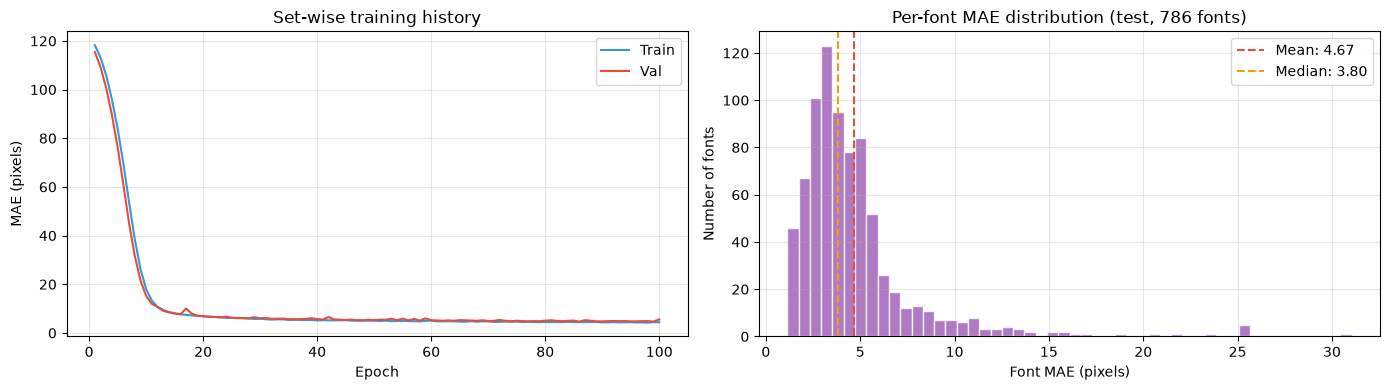

In [24]:
import matplotlib.pyplot as plt

hist = pd.read_csv(HISTORY_PATH)
fm = pd.read_csv(MODEL_DIR / "test_font_mae.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist["epoch"], hist["train_loss"], label="Train", color="#3498db")
axes[0].plot(hist["epoch"], hist["val_loss"], label="Val", color="#e74c3c")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE (pixels)")
axes[0].set_title("Set-wise training history")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(fm["mae"], bins=50, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[1].axvline(fm["mae"].mean(), color="#e74c3c", linestyle="--",
                label=f"Mean: {fm['mae'].mean():.2f}")
axes[1].axvline(fm["mae"].median(), color="#f39c12", linestyle="--",
                label=f"Median: {fm['mae'].median():.2f}")
axes[1].set_xlabel("Font MAE (pixels)")
axes[1].set_ylabel("Number of fonts")
axes[1].set_title(f"Per-font MAE distribution (test, {len(fm)} fonts)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
